In [1]:
import numpy as np
import pandas as pd
import time
import zlib
import os

from typing import Callable, Optional, Dict, Any, Tuple
from types import SimpleNamespace

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier

from pfn_cf_guided_onehot import *
from make_mock_cont import *
from get_real_datasets import *
from preprocessing import *

from __future__ import annotations
from dataclasses import dataclass

from tabpfn import TabPFNClassifier
from xgboost import XGBClassifier

from nice import NICE
import dice_ml
from dice_ml import Model
from dice_ml import Dice

#import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [2]:
try:
    from dice_ml.utils.exception import UserConfigValidationException
except ImportError:
    UserConfigValidationException = Exception  # fallback

In [3]:
def build_nice_explainer(
    *,
    X_train_sc: np.ndarray,
    y_train: np.ndarray,
    predict_fn_proba: Callable[[np.ndarray], np.ndarray],
    feature_info: Optional[FeatureInfo] = None, 
    nice_opt: str = 'none'
):
    """
    Build NICE object once. Reuse it across factual points.
    """
    from nice import NICE

    d = X_train_sc.shape[1]

    if feature_info is not None and len(getattr(feature_info, "cat_groups", [])) > 0:
        # NICE expects indices of categorical FEATURES, not one-hot columns, in some versions.
        # The safest approach for one-hot is:
        # - treat each one-hot column as categorical (cat_feat = list(all one-hot columns))
        # - and numeric = num_idx
        #
        # This is not perfect (it doesn't enforce one-hot group constraints), but it avoids scaling / distance nonsense.
        cat_cols = np.concatenate([np.asarray(g, int) for g in feature_info.cat_groups]).tolist()
        if feature_info.num_idx is not None:
            num_feat = np.asarray(feature_info.num_idx, int).tolist()
        else:
            mask = np.ones(d, dtype=bool)
            mask[np.asarray(cat_cols, int)] = False
            num_feat = np.flatnonzero(mask).tolist()
        cat_feat = cat_cols
    else:
        # continuous-only
        cat_feat = []
        num_feat = list(range(d))

    nice_obj = NICE(
        X_train=X_train_sc,
        predict_fn=predict_fn_proba,
        y_train=y_train,
        cat_feat=cat_feat,
        num_feat=num_feat,
        distance_metric="HEOM",
        num_normalization="minmax",   # OK for numeric; cat treated separately by HEOM
        optimization=nice_opt,
        justified_cf=True,
    )
    return nice_obj

@dataclass
class CFOut:
    x_cf: Optional[np.ndarray]
    rep: Dict[str, Any]
    meta: Dict[str, Any]


def _extract_cf_from_nice_result(res) -> Optional[np.ndarray]:
    """
    Tries hard to extract a CF vector from whatever NICE returns.
    Adjust based on exact return type.
    """
    if res is None:
        return None

    # Case 1: direct numpy array
    if isinstance(res, np.ndarray):
        if res.ndim == 2 and res.shape[0] == 1:
            return res[0]
        if res.ndim == 1:
            return res

    return None


def nice_cf_one(
    *,
    nice_obj,
    x_f_sc: np.ndarray,
    predict_proba_target: PredictProbaFn,
    proba_threshold: float = 0.5,
    tol: float = 1e-6,
    feature_info: Optional["FeatureInfo"] = None,
    repair_onehot: bool = False,
) -> CFOut:
    """
    Run NICE for one factual and return a standardized output.
    - validates flip wrt TARGET model
    - optional one-hot validity enforcement (strict by default; repair if requested)
    - group-aware L0 if feature_info provided
    """
    t0 = time.perf_counter()

    x_f_sc = np.asarray(x_f_sc, dtype=np.float32).reshape(-1)
    p_f = float(predict_proba_target(x_f_sc[None, :])[0])
    yhat_f = int(p_f >= proba_threshold)
    y_desired = 1 - yhat_f

    try:
        res = nice_obj.explain(x_f_sc[None, :])
    except Exception as e:
        return CFOut(
            x_cf=None,
            rep={"status": "exception", "exception": repr(e)},
            meta={"method": "NICE"},
        )

    x_cf = _extract_cf_from_nice_result(res)
    if x_cf is None:
        return CFOut(
            x_cf=None,
            rep={"status": "no_cf"},
            meta={"method": "NICE", "raw": res},
        )

    x_cf = np.asarray(x_cf, dtype=np.float32).reshape(-1)

    # --- enforce one-hot validity if categoricals exist ---
    if feature_info is not None and len(getattr(feature_info, "cat_groups", [])) > 0:
        cat_groups = [np.asarray(g, dtype=int) for g in feature_info.cat_groups]

        if repair_onehot:
            # project each group to exactly one active category
            x_cf = x_cf.copy()
            for g in cat_groups:
                j = int(g[np.argmax(x_cf[g])])
                x_cf[g] = 0.0
                x_cf[j] = 1.0
        else:
            # strict: reject invalid one-hot
            if not onehot_valid_mask(x_cf[None, :], cat_groups, tol=tol)[0]:
                dt = time.perf_counter() - t0
                return CFOut(
                    x_cf=x_cf, #None,
                    rep={"status": "invalid_onehot", "time_s": float(dt)},
                    meta={"method": "NICE", "raw": res},
                )

        # optional: enforce immutable constraints strictly (recommended for fair benchmark)
        immutable_num = getattr(feature_info, "immutable_num", frozenset())
        if immutable_num:
            for j in immutable_num:
                if abs(float(x_cf[int(j)] - x_f_sc[int(j)])) > tol:
                    dt = time.perf_counter() - t0
                    return CFOut(
                        x_cf=x_cf, #None,
                        rep={"status": "violates_immutable", "feature": int(j), "time_s": float(dt)},
                        meta={"method": "NICE", "raw": res},
                    )

    p_cf = float(predict_proba_target(x_cf[None, :])[0])
    yhat_cf = int(p_cf >= proba_threshold)

    if yhat_cf != y_desired:
        dt = time.perf_counter() - t0
        return CFOut(
            x_cf=x_cf, #None,
            rep={
                "status": "not_flipped",
                "p_f": float(p_f),
                "p_cf": float(p_cf),
                "yhat_f": int(yhat_f),
                "y_desired": int(y_desired),
                "yhat_cf": int(yhat_cf),
                "time_s": float(dt),
            },
            meta={"method": "NICE", "raw": res},
        )

    # --- metrics in model space ---
    diff = x_cf - x_f_sc

    if feature_info is not None and len(getattr(feature_info, "cat_groups", [])) > 0:
        d = x_f_sc.shape[0]
        cat_groups = [np.asarray(g, int) for g in feature_info.cat_groups]
        if getattr(feature_info, "num_idx", None) is not None:
            num_idx = np.asarray(feature_info.num_idx, int)
        else:
            cat_cols = np.zeros(d, dtype=bool)
            for g in cat_groups:
                cat_cols[g] = True
            num_idx = np.flatnonzero(~cat_cols)

        l0 = int(l0_group_aware(x_f_sc, x_cf[None, :], num_idx=num_idx, cat_groups=cat_groups, tol=tol)[0])
    else:
        l0 = int(np.sum(np.abs(diff) > tol))

    l2 = float(np.sqrt(np.sum(diff * diff)))
    dt = time.perf_counter() - t0

    rep = {
        "status": "ok",
        "p_f": float(p_f),
        "p_cf": float(p_cf),
        "yhat_f": int(yhat_f),
        "y_desired": int(y_desired),
        "l0": int(l0),
        "l2": float(l2),
        "time_s": float(dt),
    }
    meta = {"method": "NICE", "raw": res, "repaired_onehot": bool(repair_onehot)}
    return CFOut(x_cf=x_cf, rep=rep, meta=meta)

In [4]:
# -------------------------
# Model wrappers (predict_proba for class 1)
# -------------------------
def fit_models(X_tr_sc, y_tr, seed=0):
    models = {}

    # LR
    lr = LogisticRegression(max_iter=5000, solver="lbfgs", random_state=seed)
    lr.fit(X_tr_sc, y_tr)
    models["LR"] = lr

    # RF (no scaling needed but keep inputs scaled anyway for comparability)
    rf = RandomForestClassifier(
        n_estimators=400, random_state=seed, n_jobs=-1, min_samples_leaf=2
    )
    rf.fit(X_tr_sc, y_tr)
    models["RF"] = rf

    # XGB
    xgb = XGBClassifier(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        reg_alpha=0.0,
        min_child_weight=1.0,
        gamma=0.0,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=seed,
        n_jobs=-1,
    )
    xgb.fit(X_tr_sc, y_tr)
    models["XGB"] = xgb

    # TABPFN
    tp = TabPFNClassifier(device="auto")
    tp.fit(X_tr_sc, y_tr)
    models["TabPFN"] = tp

    return models


def proba_fn(model):
    return lambda X: model.predict_proba(X)[:, 1]


In [5]:
from sklearn.base import clone

def fit_models_for_dice(X_tr_raw_df, y_tr, pre, *, outcome_name="outcome", seed=0, models_sc=None):
    """
    Fit pipeline models for DiCE (pre -> estimator) on RAW training data.
    Uses clone(models_sc[name]) to preserve hyperparameters.
    """
    X_tr_raw = X_tr_raw_df.drop(columns=[outcome_name], errors="ignore")

    dice_models = {}

    for name in ["LR", "RF", "XGB"]:
        if models_sc is None or name not in models_sc:
            raise ValueError("Pass models_sc with fitted models to clone hyperparams cleanly.")
        est = clone(models_sc[name])   # keeps hyperparams, resets fitted state
        pipe = Pipeline([("pre", pre), ("model", est)])
        pipe.fit(X_tr_raw, y_tr)
        dice_models[name] = pipe

    return dice_models

In [6]:
@dataclass
class GuidedCFCache:
    X_tr_sc: np.ndarray
    predict_proba_guidance: PredictProbaFn

    feature_info: FeatureInfo | None

    # Cached outputs
    p_train: np.ndarray          # shape (n_train,)
    A: Any                       # stageA_build output

    anchors_by_class: Dict[int, np.ndarray]
    anchors_diag_by_class: Dict[int, Dict[str, Any]]

def guided_cf_build_cache(
    *,
    X_tr_sc: np.ndarray,
    predict_proba_target: PredictProbaFn,
    predict_proba_guidance: PredictProbaFn | None = None,
    stageA_random_state: int = 0,
    anchor_k: int = 200,
    anchors_random_state: int = 1,
    feature_info: FeatureInfo | None = None,
) -> GuidedCFCache:
    if predict_proba_guidance is None:
        predict_proba_guidance = predict_proba_target

    p_train = predict_proba_guidance(X_tr_sc).astype(np.float64)

    A = stageA_build(
        X_train=X_tr_sc,
        predict_proba_fn=predict_proba_guidance,
        random_state=stageA_random_state,
        feature_info=feature_info,
    )

    anchors_by_class = {}
    anchors_diag_by_class = {}

    for y_desired in (0, 1):
        anchors, diag = stageA_target_anchors_from_p(
            p_train=p_train,
            y_desired=y_desired,
            anchor_k=anchor_k,
            random_state=anchors_random_state,
        )
        anchors_by_class[y_desired] = anchors
        anchors_diag_by_class[y_desired] = diag

    return GuidedCFCache(
        X_tr_sc=X_tr_sc,
        predict_proba_guidance=predict_proba_guidance,
        feature_info=feature_info,
        p_train=p_train,
        A=A,
        anchors_by_class=anchors_by_class,
        anchors_diag_by_class=anchors_diag_by_class,
    )

def guided_cf_one_repeated(
    *,
    x_f_sc: np.ndarray,
    cache: GuidedCFCache,
    predict_proba_target: PredictProbaFn,
    n_candidates: int = 300,
    max_changed_features: int = 3,
    random_state=0,           
    feature_info= FeatureInfo | None, 
):
    # target-side decision (must stay per factual)
    p_f = float(predict_proba_target(x_f_sc[None, :])[0])
    yhat_f = int(p_f >= 0.5)
    y_desired = 1 - yhat_f

    anchors = cache.anchors_by_class[y_desired]
    if anchors.size == 0:
        return x_f_sc.copy(), {"ok": False}, {
            "error": "no_anchors",
            "y_desired": y_desired,
            "p_f": p_f,
        }

    C_sc, meta = stageB_generate(
        x_f=x_f_sc,
        X_train=cache.X_tr_sc,
        predict_proba_fn=cache.predict_proba_guidance,
        boundary_idx=cache.A.boundary_idx,
        anchors_idx=anchors,
        feature_weights=cache.A.feature_weights,
        unit_weights=getattr(cache.A, "unit_weights", None), 
        feature_info=cache.feature_info,             
        n_candidates=n_candidates,
        max_changed_features=max_changed_features,
        random_state=random_state,
    )

    x_cf_sc, rep = stageC_select_best(
        x_f=x_f_sc,
        C=C_sc,
        predict_proba_fn=predict_proba_target,
        y_desired=y_desired,
        feature_info=cache.feature_info,
    )

    meta = dict(meta)
    meta["anchors_diag"] = cache.anchors_diag_by_class[y_desired]
    meta["p_f"] = p_f
    meta["y_desired"] = y_desired

    return x_cf_sc, rep, meta

In [7]:
def stable_int_seed(*parts) -> int:
    s = "|".join(map(str, parts)).encode("utf-8")
    return zlib.crc32(s) & 0xFFFFFFFF  # 0..2^32-1

In [8]:
def l0_mixed(x_f, x_cf, feature_info, tol=1e-6):
    if feature_info is None or len(getattr(feature_info, "cat_groups", [])) == 0:
        return int(np.sum(np.abs(x_cf - x_f) > tol))

    d = x_f.shape[0]
    cat_groups = [np.asarray(g, int) for g in feature_info.cat_groups]

    if getattr(feature_info, "num_idx", None) is not None:
        num_idx = np.asarray(feature_info.num_idx, int)
    else:
        cat_cols = np.zeros(d, dtype=bool)
        for g in cat_groups:
            cat_cols[g] = True
        num_idx = np.flatnonzero(~cat_cols)

    num_changed = int(np.sum(np.abs(x_cf[num_idx] - x_f[num_idx]) > tol))

    cat_changed = 0
    for g in cat_groups:
        if np.any(np.abs(x_cf[g] - x_f[g]) > tol):
            cat_changed += 1

    return num_changed + cat_changed

In [9]:
def prepare_dataset(
    ds_in,
    *,
    rng=0,
    test_size=0.25,
    ohe_sparse=True,
    make_dense=True,
    outcome_name="outcome",          # <-- standardized target column name
    dice_clip_quantiles=None,        # e.g. (0.01, 0.99)
    dice_use_immutables=True,
):

    def dice_permitted_range_from_train(X_tr_raw_df, continuous_features, clip_quantiles=None):
        pr = {}
        for c in continuous_features:
            s = pd.to_numeric(X_tr_raw_df[c], errors="coerce")
            if clip_quantiles is None:
                lo = float(np.nanmin(s.values))
                hi = float(np.nanmax(s.values))
            else:
                qlo, qhi = clip_quantiles
                lo = float(np.nanquantile(s.values, qlo))
                hi = float(np.nanquantile(s.values, qhi))
            if np.isfinite(lo) and np.isfinite(hi) and lo <= hi:
                pr[c] = [lo, hi]
        return pr

    def dice_features_to_vary(num_cols, cat_cols):
        # keep this explicit; you can swap in your actionability logic later
        if dice_use_immutables:
            imm_num = {"age", "fnlwgt"} & set(num_cols)
            imm_cat = {"sex", "race"} & set(cat_cols)
            imm = imm_num | imm_cat
            return [c for c in list(num_cols) + list(cat_cols) if c not in imm]
        return list(num_cols) + list(cat_cols)

    # ---------------------------
    # REAL DATASET
    # ---------------------------
    if hasattr(ds_in, "X_df"):
        X_df = ds_in.X_df
        y = np.asarray(ds_in.y).astype(int, copy=False)
        num_cols, cat_cols = list(ds_in.num_cols), list(ds_in.cat_cols)

        idx = np.arange(len(X_df))
        idx_tr, idx_te = train_test_split(
            idx, test_size=test_size, stratify=y, random_state=rng
        )

        X_tr_raw_df = X_df.iloc[idx_tr].copy()
        X_te_raw_df = X_df.iloc[idx_te].copy()
        y_tr = y[idx_tr]
        y_te = y[idx_te]

        # Add standardized outcome column for DiCE
        X_tr_raw_df[outcome_name] = y_tr
        X_te_raw_df[outcome_name] = y_te

        # Fit preprocessing on train only (features only)
        pre = make_preprocessor(num_cols, cat_cols, ohe_sparse=ohe_sparse)
        pre.fit(X_tr_raw_df.drop(columns=[outcome_name]))

        X_tr_sc = pre.transform(X_tr_raw_df.drop(columns=[outcome_name]))
        X_te_sc = pre.transform(X_te_raw_df.drop(columns=[outcome_name]))

        if make_dense and hasattr(X_tr_sc, "toarray"):
            X_tr_sc = X_tr_sc.toarray()
            X_te_sc = X_te_sc.toarray()

        X_tr_sc = np.asarray(X_tr_sc, dtype=np.float64)
        X_te_sc = np.asarray(X_te_sc, dtype=np.float64)

        # FeatureInfo only if categoricals exist (your rule)
        if len(cat_cols) == 0:
            feature_info = None
        else:
            num_idx, cat_groups = build_feature_info_from_pre(pre, num_cols, cat_cols)
            #immutable_num = safe_immutable_num(num_cols, num_idx, {"age", "fnlwgt"})
            #immutable_cat = safe_immutable_cat(cat_cols, {"sex", "race"})
            immutable_num = safe_immutable_num(num_cols, num_idx, ds_in.immutables.num)
            immutable_cat = safe_immutable_cat(cat_cols, ds_in.immutables.cat)
            immutables = getattr(ds_in, "immutables", ImmutableSpec.empty())
            feature_info = FeatureInfo(
                num_idx=num_idx,
                cat_groups=cat_groups,
                #immutables=immutables,
                immutable_num=immutable_num,
                immutable_cat=immutable_cat,
            )

        # DiCE spec (raw space)
        continuous_features = list(num_cols)
        categorical_features = list(cat_cols)
        dice_spec = {
            "continuous_features": continuous_features,
            "categorical_features": categorical_features,
            "outcome_name": outcome_name,
            "features_to_vary": dice_features_to_vary(num_cols, cat_cols),
            "permitted_range": dice_permitted_range_from_train(
                X_tr_raw_df, continuous_features, clip_quantiles=dice_clip_quantiles
            ),
        }

        meta = dict(getattr(ds_in, "meta", {}) or {})
        meta.update({
            "n_rows": int(len(X_df)),
            "n_cols_model": int(X_tr_sc.shape[1]),
            "idx_tr": idx_tr,
            "idx_te": idx_te,
            "num_cols": continuous_features,
            "cat_cols": categorical_features,
            "outcome_name": outcome_name,
        })

        return X_tr_sc, X_te_sc, y_tr, y_te, feature_info, meta, pre, X_tr_raw_df, X_te_raw_df, dice_spec

    # ---------------------------
    # SYNTHETIC DATASET
    # ---------------------------
    X = np.asarray(ds_in.X, dtype=np.float64)
    y = np.asarray(ds_in.y, dtype=int)

    X_tr_sc, X_te_sc, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=rng
    )

    d = X.shape[1]
    cols = [f"f{i}" for i in range(d)]
    X_tr_raw_df = pd.DataFrame(X_tr_sc, columns=cols)
    X_te_raw_df = pd.DataFrame(X_te_sc, columns=cols)

    # Add standardized outcome for DiCE
    X_tr_raw_df[outcome_name] = y_tr
    X_te_raw_df[outcome_name] = y_te

    feature_info = None
    pre = None

    dice_spec = {
        "continuous_features": cols,
        "categorical_features": [],
        "outcome_name": outcome_name,
        "features_to_vary": cols,
        "permitted_range": dice_permitted_range_from_train(
            X_tr_raw_df, cols, clip_quantiles=dice_clip_quantiles
        ),
    }

    meta = dict(getattr(ds_in, "meta", {}) or {})
    meta.update({
        "n_rows": int(X.shape[0]),
        "n_cols_model": int(d),
        "idx_tr": None,
        "idx_te": None,
        "num_cols": cols,
        "cat_cols": [],
        "outcome_name": outcome_name,
    })

    return X_tr_sc, X_te_sc, y_tr, y_te, feature_info, meta, pre, X_tr_raw_df, X_te_raw_df, dice_spec

In [10]:
def _mk_rep(ok, status, msg=None, **extra):
    rep = {"ok": bool(ok), "status": str(status)}
    if msg is not None:
        rep["msg"] = str(msg)
    rep.update(extra)
    return rep


def dice_to_standard_out(
    *,
    dice_exp,                 # object returned by dice.generate_counterfactuals(...)
    pre,                      # fitted preprocessor (ColumnTransformer / Pipeline step)
    x_f_raw_df,               # factual row as 1-row DF (features only, no outcome col)
    dice_spec,                # dict with outcome_name, etc.
    pick="closest_l2_scaled", # how to choose among multiple CFs
    make_dense=True,
):
    """
    Convert DiCE explanation -> (x_cf_sc, rep, meta) for your benchmark.

    Returns:
      x_cf_sc: 1D numpy float64 in scaled/model space, or None if failed
      rep: dict with ok/status and basic diagnostics
      meta: dict with raw CF df, chosen index, distances, etc.
    """

    outcome_name = dice_spec["outcome_name"]

    # Extract final CF dataframe
    try:
        cf_df = dice_exp.cf_examples_list[0].final_cfs_df
    except Exception as e:
        return None, _mk_rep(False, "dice_no_output", str(e)), {"dice_exp": dice_exp}

    if cf_df is None or len(cf_df) == 0:
        return None, _mk_rep(False, "dice_no_cfs"), {"cf_df": cf_df}

    # Some dice versions include outcome column in CF df; remove it for transform
    cf_feat_df = cf_df.copy()
    if outcome_name in cf_feat_df.columns:
        cf_feat_df = cf_feat_df.drop(columns=[outcome_name])

    # Ensure columns order matches x_f_raw_df (important!)
    cf_feat_df = cf_feat_df[x_f_raw_df.columns]

    # Transform all CF candidates to scaled space so we can pick one consistently
    #X_cf_sc = pre.transform(cf_feat_df)
    if pre is None:
        # No preprocessing was applied during training: treat raw numeric as model-space
        X_cf_sc = cf_feat_df.to_numpy(dtype=np.float64, copy=False)
    else:
        X_cf_sc = pre.transform(cf_feat_df)
        if make_dense and hasattr(X_cf_sc, "toarray"):
            X_cf_sc = X_cf_sc.toarray()
        X_cf_sc = X_cf_sc.astype(np.float64, copy=False)

    if make_dense and hasattr(X_cf_sc, "toarray"):
        X_cf_sc = X_cf_sc.toarray()

    X_cf_sc = np.asarray(X_cf_sc, dtype=np.float64)

    # Also transform factual to scaled (for distance/pick logic)
    #X_f_sc = pre.transform(x_f_raw_df)
    if pre is None:
        X_f_sc = x_f_raw_df.to_numpy(dtype=np.float64, copy=False).reshape(1, -1)
    else:
        X_f_sc = pre.transform(x_f_raw_df)

    if make_dense and hasattr(X_f_sc, "toarray"):
        X_f_sc = X_f_sc.toarray()
    X_f_sc = np.asarray(X_f_sc, dtype=np.float64).reshape(1, -1)

    # Pick best CF among candidates
    if pick == "first":
        j = 0
        scores = None
    elif pick == "closest_l2_scaled":
        dif = X_cf_sc - X_f_sc
        scores = np.sqrt((dif * dif).sum(axis=1))
        j = int(np.argmin(scores))
    else:
        raise ValueError(f"Unknown pick policy: {pick}")

    x_cf_sc = X_cf_sc[j].copy()

    meta = {
        "n_cfs_returned": int(len(cf_df)),
        "chosen_idx": int(j),
        "pick_policy": pick,
        "cf_raw_df": cf_df,                 # includes outcome if DiCE returned it
        "cf_features_df": cf_feat_df,        # features only, aligned cols
    }
    if scores is not None:
        meta["pick_scores"] = scores

    rep = _mk_rep(True, "dice_ok", chosen_idx=j, n_cfs=len(cf_df))

    return x_cf_sc, rep, meta

In [11]:
def validate_cf(
    *,
    x_cf_sc,
    x_f_sc,
    predict_fn_proba,
    proba_threshold=0.5,
    tol=1e-8,
):
    """
    Validate a counterfactual in model space.

    Returns:
      ok: bool
      status: short string code
      info: dict with diagnostics
    """
    info = {}

    # 1) Existence
    if x_cf_sc is None:
        return False, "no_cf", info

    x_cf_sc = np.asarray(x_cf_sc)

    # 2) Shape
    if x_cf_sc.ndim != 1:
        return False, "bad_shape", {"shape": x_cf_sc.shape}

    # 3) Finite values
    if not np.all(np.isfinite(x_cf_sc)):
        return False, "non_finite", {}

    # 4) Non-trivial change
    delta = x_cf_sc - x_f_sc
    l0 = int(np.sum(np.abs(delta) > tol))
    info["l0"] = l0

    if l0 == 0:
        return False, "no_change", info

    # 5) Model flip
    p_cf = predict_fn_proba(x_cf_sc.reshape(1, -1))[0]
    p_f  = predict_fn_proba(x_f_sc.reshape(1, -1))[0]

    info["proba_f"] = p_f
    info["proba_cf"] = p_cf

    # binary classification assumption
    p1_f  = float(p_f[1]) if len(p_f) == 2 else float(p_f[0])
    p1_cf = float(p_cf[1]) if len(p_cf) == 2 else float(p_cf[0])

    flipped = (p1_f < proba_threshold) and (p1_cf >= proba_threshold)
    flipped |= (p1_f >= proba_threshold) and (p1_cf < proba_threshold)

    if not flipped:
        return False, "no_flip", info

    # 6) Norms (for reporting)
    info["l2"] = float(np.linalg.norm(delta))

    return True, "ok", info

In [12]:
def run_benchmark(
    *,
    X_tr_sc, X_te_sc, y_tr, y_te,
    models: dict,
    factual_indices: np.ndarray,
    methods=("guided", "nice", "dice"),
    seed=0,
    # guided hyperparams
    guided_n_candidates=1000,
    guided_max_changed_features=8,
    guided_anchor_k=250,
    # cache seeds (keep separate so we don’t accidentally “randomize” anchors per factual)
    guided_stageA_random_state=0,
    guided_anchors_random_state=1,
    feature_info=None,
    pre=None,
    X_tr_raw=None,
    X_te_raw=None,
    dice_spec=None,
    include_vectors: bool = True,
    max_vec_len: int | None = None,   # e.g. 200 to truncate stored vectors
):
    def _maybe_trunc(v: np.ndarray) -> list:
        v = np.asarray(v).reshape(-1)
        if (max_vec_len is not None) and (v.size > max_vec_len):
            return v[:max_vec_len].tolist()
        return v.tolist()
        
    rows = []

    for model_name, model in models.items():
        print("Working with model", model_name)
        pp = proba_fn(model)
        pp_guidance = proba_fn(models["LR"])
        pp_target = proba_fn(model)

        # sanity metrics on test
        p_te = pp(X_te_sc)
        acc = accuracy_score(y_te, (p_te >= 0.5).astype(int))
        auc = roc_auc_score(y_te, p_te)

        # --- build NICE once per model (if needed) ---
        nice_obj = None
        if "nice" in methods:
            if model_name=='TabPFN':
                nice_opt = 'none'
            else:
                nice_opt = 'sparsity'
            predict_fn_proba = lambda X: model.predict_proba(X)  # 2D proba
            nice_obj = build_nice_explainer(
                X_train_sc=X_tr_sc,
                y_train=y_tr,
                predict_fn_proba=predict_fn_proba, 
                feature_info=feature_info,
                nice_opt = nice_opt,
            )
        
        if "dice" in methods:
            dice_data = dice_ml.Data(
                dataframe=X_tr_raw,
                continuous_features=dice_spec["continuous_features"],
                categorical_features=dice_spec["categorical_features"],
                outcome_name=dice_spec["outcome_name"]
            )
            if model_name!='TabPFN':
                dice_model = dice_ml.Model(model=dice_spec['models'][model_name], backend="sklearn")
                dice_exp = Dice(dice_data, dice_model,method='genetic')

        # --- build Guided cache once per model (if needed) ---
        guided_cache = None
        if "guided" in methods:
            guided_cache = guided_cf_build_cache(
                X_tr_sc=X_tr_sc,
                predict_proba_target=pp_target,
                predict_proba_guidance=pp_guidance,
                stageA_random_state=guided_stageA_random_state,
                anchor_k=guided_anchor_k,
                anchors_random_state=guided_anchors_random_state,
                feature_info=feature_info,
            )

        for idx in factual_indices:
            x_f = X_te_sc[idx]
            p_f = float(pp(x_f[None, :])[0])
            yhat_f = int(p_f >= 0.5)
            y_desired = 1 - yhat_f

            for method in methods:
                t0 = time.perf_counter()
                if method == "guided":
                    guided_rs = stable_int_seed(seed, model_name, "guided", int(idx))
                    x_cf, rep, meta = guided_cf_one_repeated(
                        x_f_sc=x_f,
                        cache=guided_cache,
                        predict_proba_target=pp,
                        n_candidates=guided_n_candidates,
                        max_changed_features=guided_max_changed_features,
                        random_state=guided_rs,
                        feature_info=feature_info, 
                    )

                elif method == "nice":
                    out = nice_cf_one(
                        nice_obj=nice_obj,
                        x_f_sc=x_f,
                        predict_proba_target=pp, 
                        proba_threshold=0.5,
                        tol=1e-6,
                        feature_info=feature_info,
                        repair_onehot=False,   # for a strict benchmark; True for simply “best effort”
                    )
                    x_cf, rep, meta = out.x_cf, out.rep, out.meta
                
                elif method == 'dice':
                    if model_name!='TabPFN':
                        x_f_dice = X_te_raw.drop(columns=[dice_spec["outcome_name"]]).iloc[[idx]]
                        #print(x_f_dice)
                        try:
                            x_cf_dice = dice_exp.generate_counterfactuals(
                                query_instances=x_f_dice,
                                total_CFs=1,
                                desired_class="opposite",
                                features_to_vary=dice_spec["features_to_vary"],
                                permitted_range=dice_spec["permitted_range"],
                                proximity_weight=1.0, 
                                diversity_weight=0.0,
                                sparsity_weight=1.0,
                            )

                        except UserConfigValidationException as e:
                            x_cf_dice = None
                            rep = {
                                "ok": False,
                                "status": "dice_invalid_config",
                                "msg": str(e),
                            }
                            meta = {
                                "exception": "UserConfigValidationException",
                                "exception_msg": str(e),
                            }
                            #return None, rep, meta

                        except Exception as e:
                            # genuine runtime error (bug, numerical issue, etc.)
                            x_cf_dice = None
                            rep = {
                                "ok": False,
                                "status": "dice_exception",
                                "msg": str(e),
                            }
                            meta = {
                                "exception": type(e).__name__,
                                "exception_msg": str(e),
                            }

                        x_cf_sc, rep, meta = dice_to_standard_out(
                            dice_exp=x_cf_dice,
                            pre=pre,
                            x_f_raw_df=x_f_dice,
                            dice_spec=dice_spec,
                            pick="closest_l2_scaled",
                            make_dense=True,
                        )
                        x_cf = x_cf_sc     # Prevent state leakage from previous method
                        ok, status, val_info = validate_cf(
                            x_cf_sc=x_cf_sc,
                            x_f_sc=x_f.ravel(),
                            predict_fn_proba=predict_fn_proba,
                            proba_threshold=0.5,
                        )
                        out = SimpleNamespace(x_cf=x_cf_sc, rep=rep, meta=meta)
                        rep['status'] = status

                    else:   
                        #print("Skipping TabPFN with DiCE as it takes too long..")
                        continue
                    
                else:
                    raise ValueError(f"Unknown method: {method}")

                dt = time.perf_counter() - t0
                ok = (x_cf is not None) and (rep.get("status") == "ok")
                
                if ok:
                    p_cf = float(pp(x_cf[None, :])[0])
                    flip_ok = int((p_cf >= 0.5) == y_desired)
                    # compute metrics
                    diff = x_cf - x_f
                    l0 = l0_mixed(x_f, x_cf, feature_info, tol=1e-6)
                    #l0_units = l0_mixed(x_f, x_cf, feature_info, tol=1e-6)
                    #l0_cols = int(np.sum(np.abs(x_cf - x_f) > 1e-6))  # debug only

                    l2 = float(np.sqrt(np.sum(diff * diff)))
                    margin = abs(p_cf - 0.5)

                    # quick debug summary: which columns moved (truncated)
                    changed_idx = np.flatnonzero(np.abs(diff) > 1e-6)
                    changed_idx_show = changed_idx[:50].tolist()  # cap so rows stay readable
                else:
                    p_cf = np.nan #float(pp(x_cf[None, :])[0]) #np.nan
                    flip_ok = 0
                    l0, l0_cols, l2, margin = np.nan, np.nan, np.nan, np.nan
                    diff = None
                    changed_idx_show = []

                row = {
                    "model": model_name,
                    "method": method,
                    "idx": int(idx),
                    "ok": bool(ok),
                    "flip_ok": int(flip_ok),
                    "p_f": float(p_f),
                    "p_cf": float(p_cf) if np.isfinite(p_cf) else np.nan,
                    "margin_cf": float(margin) if np.isfinite(margin) else np.nan,
                    "l0": l0,                 # unit-aware
                    "l2": l2,
                    "time_s": float(dt),
                    "clf_acc": float(acc),
                    "clf_auc": float(auc),
                    "status": rep.get("status"),
                    "rep": rep,
                    "changed_idx": changed_idx_show,
                }

                if include_vectors:
                    row["x_f"] = _maybe_trunc(x_f)
                    row["x_cf"] = _maybe_trunc(x_cf) if ok else None
                    row["diff"] = _maybe_trunc(diff) if (ok and diff is not None) else None

                rows.append(row)

    return pd.DataFrame(rows)

In [13]:
def run_over_datasets(
    datasets,
    *,
    seeds=(0, 1, 2),
    n_factual=5,
    methods=("guided", "nice", "dice"),
    guided_max_changed_features=4,
    guided_n_candidates=1000,
):
    all_rows = []
    pre_dict = {}
    print("-------------------------")
    for ds_in in datasets:
        print("Dataset in", ds_in.name)
        print("-------------------------")
        for seed in seeds:
            X_tr, X_te, y_tr, y_te, feature_info, meta, pre, X_tr_raw, X_te_raw, dice_spec = prepare_dataset(ds_in, rng=seed)
            pre_dict[ds_in.name] = pre

            models = fit_models(X_tr, y_tr, seed=seed)
            dice_spec['models'] = fit_models_for_dice(X_tr_raw, y_tr, pre, outcome_name=dice_spec["outcome_name"], seed=seed, models_sc=models)

            rng = np.random.default_rng(seed)
            factual_indices = rng.choice(X_te.shape[0], size=min(n_factual, X_te.shape[0]), replace=False)

            df = run_benchmark(
                X_tr_sc=X_tr,
                X_te_sc=X_te,
                y_tr=y_tr,
                y_te=y_te,
                models=models,
                factual_indices=factual_indices,
                methods=methods,
                seed=seed,
                guided_max_changed_features=guided_max_changed_features,
                guided_n_candidates=guided_n_candidates,
                feature_info=feature_info,
                pre=pre,
                X_tr_raw=X_tr_raw,
                X_te_raw=X_te_raw,
                dice_spec=dice_spec,
            )

            # attach identifiers + meta (don’t explode columns; keep only what you need)
            df["dataset"] = getattr(ds_in, "name", meta.get("openml_name", "unknown"))
            df["seed"] = seed
            df["n_cols_model"] = meta.get("n_cols_model")
            df["n_rows"] = meta.get("n_rows")

            all_rows.append(df)
            print("-------------------------")

    return pd.concat(all_rows, ignore_index=True), pre_dict

In [31]:
#os.environ["TQDM_DISABLE"] = "1"
real_datasets = load_many(["adult", "credit-g", "breast_cancer", "diabetes", "gmsc", "ca_housing"], openml_version=2) #
suite = generate_make_classification_suite(
        n_datasets=30,
        n_samples=1000,
        feature_grid=(5, 10, 20, 40, 80),
        redundancy_grid=(0.0, 0.25, 0.5, 0.75),
        informative_frac=0.3,
        class_sep=1.2,
        flip_y=0.1,
        random_state=42,
    )

# NB that for TabPFN we run NICE without optimization. For everything else we use sparsity
#df_all, pre_dict = run_over_datasets(real_datasets[1:], seeds=(0,), n_factual=2, guided_n_candidates=1000)
#df_all, pre_dict = run_over_datasets(suite, seeds=(0,), n_factual=2, guided_n_candidates=1000)
df_all2, pre_dict2 = run_over_datasets(suite, seeds=(0,), n_factual=2, guided_n_candidates=1000,guided_max_changed_features=8)

/Users/leo/Documents/cyi/repos/tabpfn/get_real_datasets.py:193: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  y = pd.to_numeric(y, errors="ignore")


-------------------------
Dataset in mc_f5_red3_inf2_seed1405681631
-------------------------
Working with model LR


100%|██████████| 1/1 [00:00<00:00, 45.19it/s]

Working with model RF



100%|██████████| 1/1 [00:00<00:00,  2.21it/s]


...


100%|██████████| 1/1 [00:00<00:00,  2.14it/s]


Working with model XGB


100%|██████████| 1/1 [00:00<00:00, 28.16it/s]

Working with model TabPFN


-------------------------


In [16]:
success = (df_all
           .groupby(["dataset","model","method"])["flip_ok"]
           .mean()
           .reset_index())

perf = (df_all
        .groupby(["dataset","model","method"])[["l0","l2","margin_cf","time_s"]]
        .median()
        .reset_index())
print(success)
print("=============================================================================")
print(perf)

                              dataset   model  method  flip_ok
0     mc_f10_red0_inf3_seed1990212658      LR    dice      1.0
1     mc_f10_red0_inf3_seed1990212658      LR  guided      1.0
2     mc_f10_red0_inf3_seed1990212658      LR    nice      1.0
3     mc_f10_red0_inf3_seed1990212658      RF    dice      1.0
4     mc_f10_red0_inf3_seed1990212658      RF  guided      1.0
..                                ...     ...     ...      ...
325  mc_f80_red56_inf24_seed594336917  TabPFN  guided      0.5
326  mc_f80_red56_inf24_seed594336917  TabPFN    nice      1.0
327  mc_f80_red56_inf24_seed594336917     XGB    dice      1.0
328  mc_f80_red56_inf24_seed594336917     XGB  guided      1.0
329  mc_f80_red56_inf24_seed594336917     XGB    nice      1.0

[330 rows x 4 columns]
                              dataset   model  method    l0        l2  \
0     mc_f10_red0_inf3_seed1990212658      LR    dice  10.0  2.474082   
1     mc_f10_red0_inf3_seed1990212658      LR  guided   1.5  0.837156   
2

/var/folders/v3/8m8d5hfj2zdby10rq6l2ttyw0000gn/T/ipykernel_40083/1582707064.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(


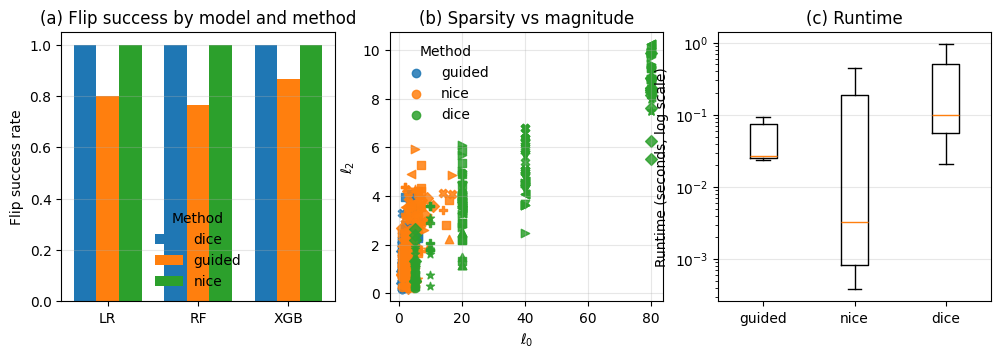

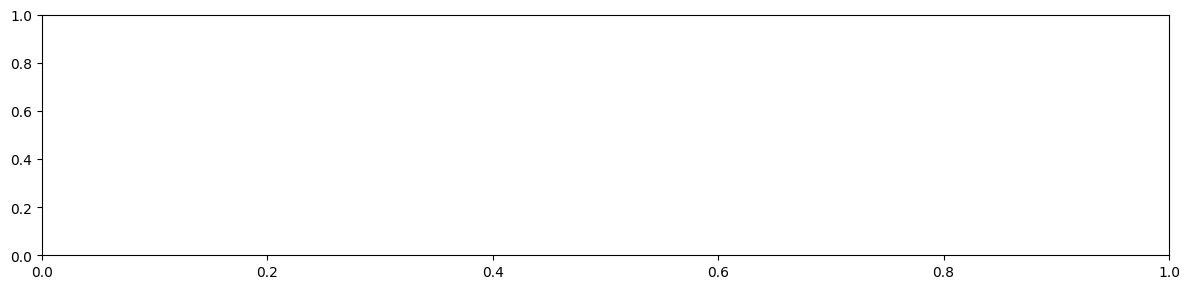

In [39]:
def plot_cf_summary(df):
    df = df[df["model"] != "TabPFN"].copy()
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

    # ---------------------------
    # (1) Flip success rate
    # ---------------------------
    # rate = df.groupby("method", as_index=False)["flip_ok"].mean()

    # axes[0].bar(rate["method"], rate["flip_ok"])
    # axes[0].set_ylim(0, 1.05)
    # axes[0].set_ylabel("Flip success rate")
    # axes[0].set_title("(a) Flip success")
    # axes[0].grid(axis="y", alpha=0.3)

    rate = (
        df.groupby(["model", "method"], as_index=False)["flip_ok"]
        .mean()
    )

    models = rate["model"].unique()
    methods = rate["method"].unique()

    x = np.arange(len(models))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 3))

    for i, method in enumerate(methods):
        vals = [
            rate[(rate["model"] == m) & (rate["method"] == method)]["flip_ok"].values[0]
            if not rate[(rate["model"] == m) & (rate["method"] == method)].empty
            else 0.0
            for m in models
        ]
        axes[0].bar(x + (i - (len(methods)-1)/2) * width, vals, width, label=method)

    axes[0].set_xticks(x)
    axes[0].set_xticklabels(models)
    axes[0].set_ylim(0, 1.05)
    axes[0].set_ylabel("Flip success rate")
    axes[0].set_title("(a) Flip success by model and method")
    axes[0].legend(title="Method", frameon=False)
    axes[0].grid(axis="y", alpha=0.3)

    # ---------------------------
    # (2) l0 vs l2 scatter
    # ---------------------------
    methods = df["method"].unique()
    datasets = df["dataset"].unique()

    cmap = plt.get_cmap("tab10")
    method_color = {m: cmap(i) for i, m in enumerate(methods)}

    markers = ["o", "s", "D", "^", "v", "<", ">", "P", "X", "*"]
    marker_map = {ds: markers[i % len(markers)] for i, ds in enumerate(datasets)}

    for method in methods:
        sub_m = df[df["method"] == method]
        for ds in datasets:
            sub = sub_m[sub_m["dataset"] == ds]
            if sub.empty:
                continue
            axes[1].scatter(
                sub["l0"],
                sub["l2"],
                color=method_color[method],
                marker=marker_map[ds],
                alpha=0.85,
                label=method if ds == datasets[0] else None,
            )

    axes[1].set_xlabel(r"$\ell_0$")
    axes[1].set_ylabel(r"$\ell_2$")
    axes[1].set_title("(b) Sparsity vs magnitude")
    #axes[1].set_xlim([0,15])
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(title="Method", frameon=False)

    # ---------------------------
    # (3) Runtime distribution
    # ---------------------------
    data = [df[df["method"] == m]["time_s"].values for m in methods]

    axes[2].boxplot(
        data,
        labels=methods,
        showfliers=False,
    )
    axes[2].set_yscale("log")  # runtime spans orders of magnitude
    axes[2].set_ylabel("Runtime (seconds, log scale)")
    axes[2].set_title("(c) Runtime")
    axes[2].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    #plt.show()
plot_cf_summary(df_all)

/var/folders/v3/8m8d5hfj2zdby10rq6l2ttyw0000gn/T/ipykernel_40083/2197375651.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(


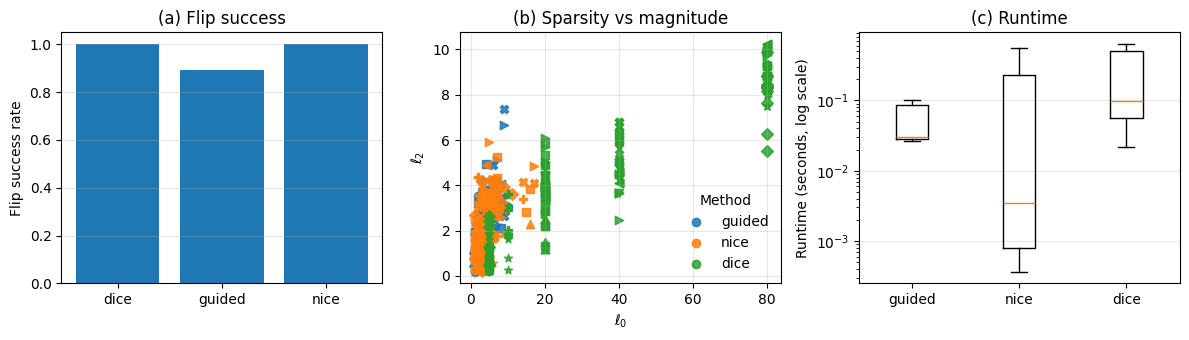

In [36]:
plot_cf_summary(df_all2)

In [19]:
#df_all[(df_all.method.isin(["dice","nice"]))&(df_all.dataset=='mc_f20_red5_inf6_seed1843824992')]

In [18]:
i = 220
ds_ind = 1
ds_in = real_datasets[ds_ind].name
model_in = 'dice'
cf_method = 'guided'
sel = (df_all.idx==i)&(df_all.dataset==ds_in)&(df_all.model==model_in)&(df_all.method==cf_method)
df_comp = pd.concat([
    pd.Series(inverse_preprocess(df_all[sel]['x_f'].iloc[0],pre_dict[ds_in],real_datasets[ds_ind].num_cols,real_datasets[ds_ind].cat_cols)),
    pd.Series(inverse_preprocess(df_all[sel]['x_cf'].iloc[0],pre_dict[ds_in],real_datasets[ds_ind].num_cols,real_datasets[ds_ind].cat_cols))
], axis=1).rename(columns={0:'x_f',1:'x_cf'})
#df_comp['change'] = abs(df_comp['x_cf'] - df_comp['x_f'])>1e-6
df_comp

IndexError: single positional indexer is out-of-bounds

In [22]:
def plot_l0_vs_l2(df):
    methods = ['dice', 'nice', 'guided'] #df["method"].unique()
    datasets = df["dataset"].unique()

    # Explicit color map for methods
    cmap = plt.get_cmap("tab10")
    method_color = {m: cmap(i) for i, m in enumerate(methods)}

    # Marker map for datasets (no legend)
    markers = ["o", "s", "D", "^", "v", "<", ">", "P", "X", "*"]
    marker_map = {ds: markers[i % len(markers)] for i, ds in enumerate(datasets)}

    fig, ax = plt.subplots(figsize=(6, 4))

    for method in methods:
        sub_m = df[df["method"] == method]
        for ds in datasets:
            sub = sub_m[sub_m["dataset"] == ds]
            if sub.empty:
                continue

            ax.scatter(
                sub["l0"],
                sub["l2"],
                color=method_color[method],     # ← FIXED
                marker=marker_map[ds],
                alpha=0.85,
                label=method if ds == datasets[0] else None,
            )

    ax.set_xlabel(r"$\ell_0$ (number of changed features)")
    ax.set_ylabel(r"$\ell_2$ distance")
    ax.set_xlim([0,15])
    ax.set_title("Sparsity vs Magnitude of Counterfactuals")

    ax.legend(title="Method", frameon=False)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

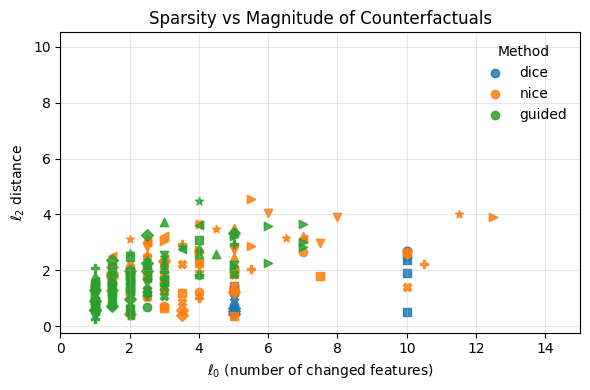

In [23]:
plot_l0_vs_l2(perf)

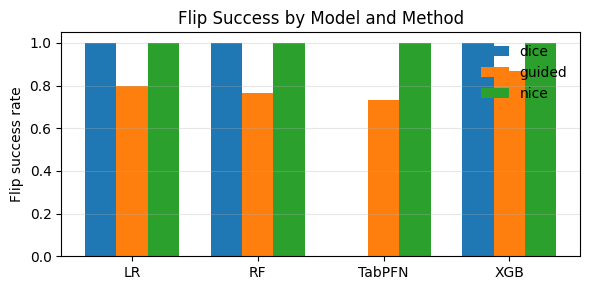

In [24]:
rate = (
    success
    .groupby(["model", "method"], as_index=False)["flip_ok"]
    .mean()
)

models = rate["model"].unique()
methods = rate["method"].unique()

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(6, 3))

for i, method in enumerate(methods):
    vals = [
        rate[(rate["model"] == m) & (rate["method"] == method)]["flip_ok"].values[0]
        if not rate[(rate["model"] == m) & (rate["method"] == method)].empty
        else 0.0
        for m in models
    ]
    ax.bar(x + (i - 1) * width, vals, width, label=method)

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("Flip success rate")
ax.set_ylim(0, 1.05)
ax.set_title("Flip Success by Model and Method")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

KeyError: 'mc_f10_red0_inf3_seed1990212658'

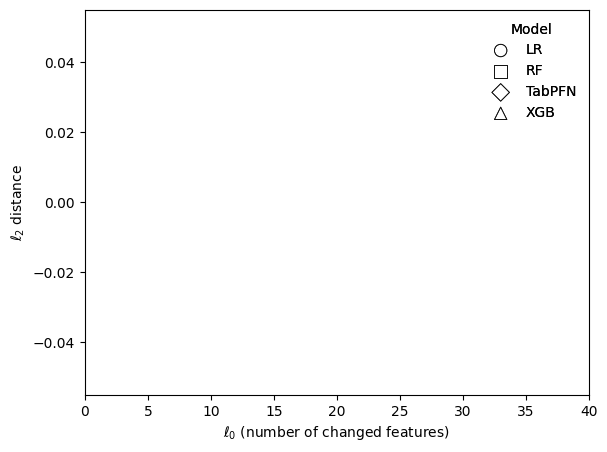

In [ ]:
# assuming your dataframe is called perf
df = perf.copy()

# --- encodings ---
datasets = df["dataset"].unique()
models = df["model"].unique()

color_map = {
    "breast_cancer": "tab:blue",
    "credit-g": "tab:orange",
    "diabetes_binarized": "tab:green",
}

marker_map = {
    "LR": "o",
    "RF": "s",
    "XGB": "^",
    "TabPFN": "D",
}

fig, ax = plt.subplots(figsize=(6.5, 5))

for model in models:
    sub = df[df["model"] == model]
    try:
        ax.scatter(
            sub["l0"],
            sub["l2"],
            c=sub["dataset"].map(color_map),
            marker=marker_map.get(model, "o"),
            s=80,
            alpha=0.85,
            edgecolor="black",
            linewidth=0.6,
            label=model,
        )
    except Exception:
        continue

# axis labels
ax.set_xlabel(r"$\ell_0$ (number of changed features)")
ax.set_ylabel(r"$\ell_2$ distance")
ax.set_xlim([0,40])

# legends
model_legend = ax.legend(title="Model", loc="upper right",frameon=False)
ax.add_artist(model_legend)

dataset_handles = [
    plt.Line2D([0], [0], marker="o", color="w",
               label=ds, markerfacecolor=color_map[ds], markersize=8)
    for ds in datasets
]
ax.legend(handles=dataset_handles, title="Dataset", loc="lower right",frameon=False)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

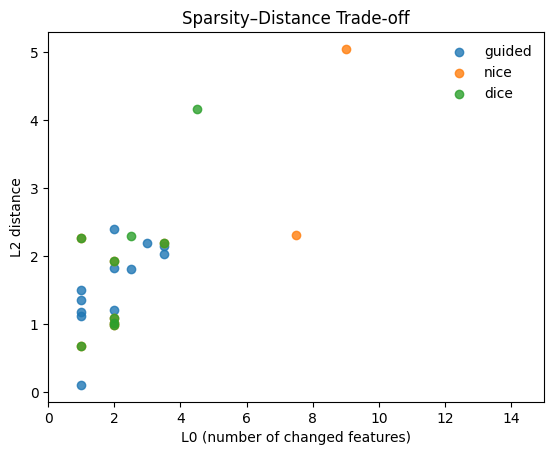

In [ ]:
plt.figure()
for method in ["guided", "nice","dice"]:
    sub = perf[(perf["method"] == method)]
    plt.scatter(
        sub["l0"], sub["l2"],
        label=method,
        alpha=0.8
    )

plt.xlabel("L0 (number of changed features)")
plt.ylabel("L2 distance")
plt.legend(frameon=False)
plt.title("Sparsity–Distance Trade-off")
plt.xlim([0,15])
plt.show()

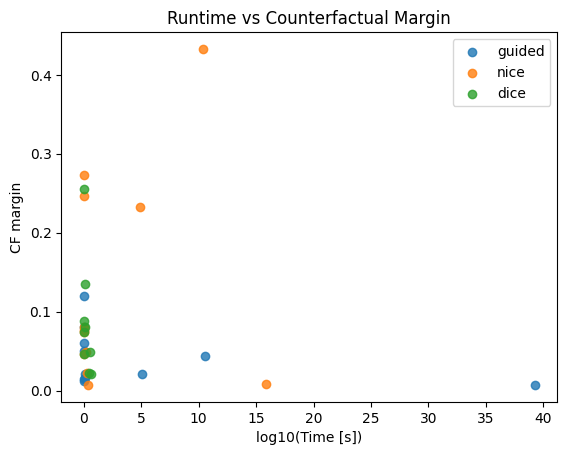

In [ ]:
plt.figure()
for method in ["guided", "nice","dice"]:
    sub = perf[(perf["method"] == method)] #& (~df["failed"])]
    plt.scatter(
        sub["time_s"], sub["margin_cf"],
        label=method,
        alpha=0.8
    )

plt.xlabel("log10(Time [s])")
plt.ylabel("CF margin")
plt.legend()
plt.title("Runtime vs Counterfactual Margin")
plt.show()


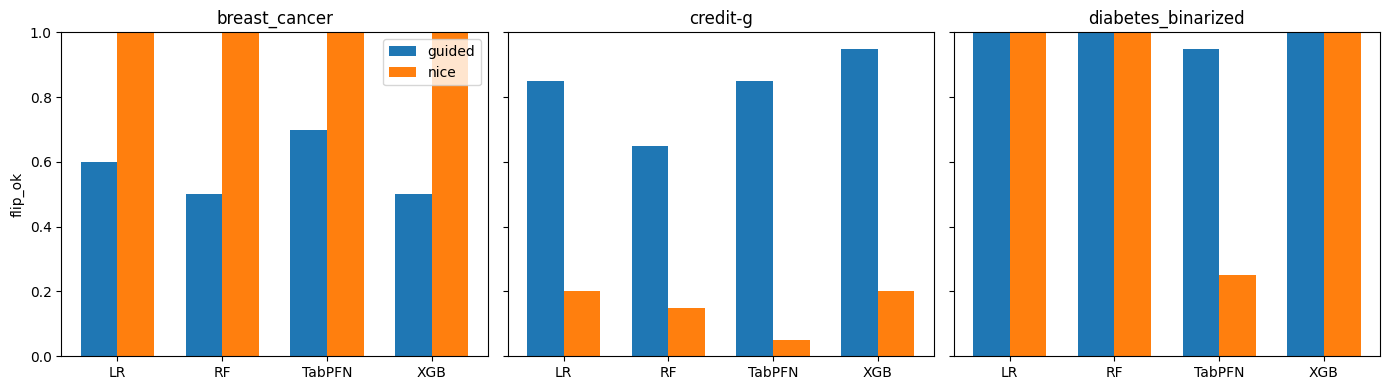

In [ ]:
datasets = success["dataset"].unique()
models = success["model"].unique()
methods = ["guided", "nice"]

fig, axes = plt.subplots(1, len(datasets), figsize=(14, 4), sharey=True)

if len(datasets) == 1:
    axes = [axes]

for ax, ds in zip(axes, datasets):
    sub = success[success["dataset"] == ds]

    x = np.arange(len(models))
    width = 0.35

    for i, method in enumerate(methods):
        vals = [
            sub[(sub["model"] == m) & (sub["method"] == method)]["flip_ok"].values[0]
            for m in models
        ]
        ax.bar(x + (i - 0.5) * width, vals, width, label=method)

    ax.set_title(ds)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylim(0, 1)

axes[0].set_ylabel("flip_ok")
axes[0].legend()

plt.tight_layout()
plt.show()

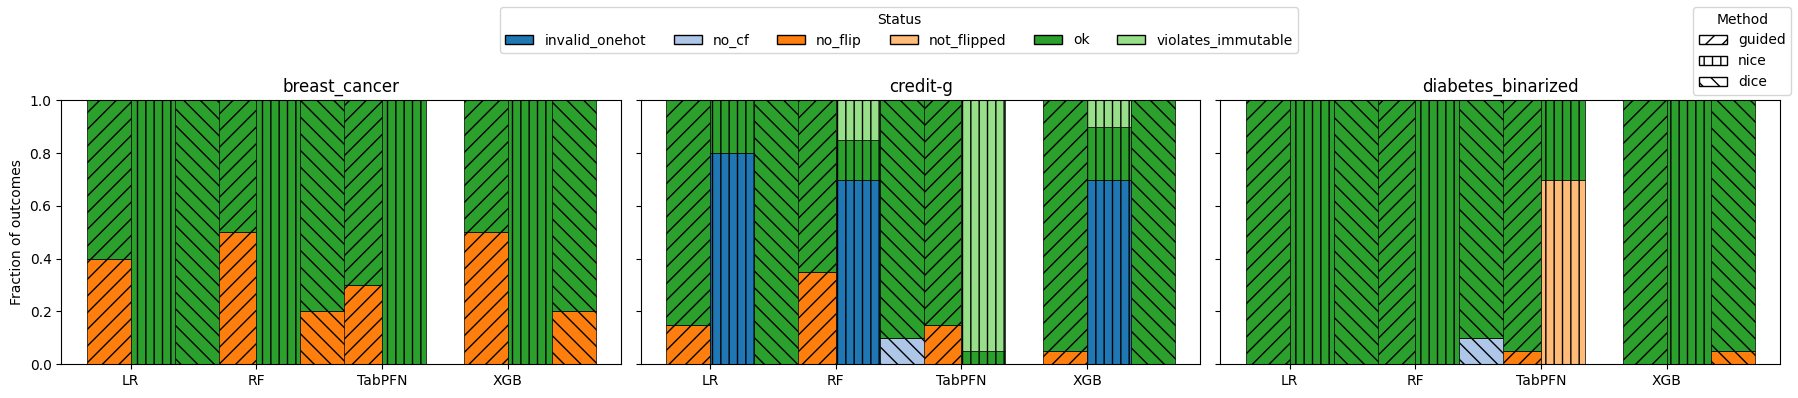

In [ ]:
statuses = (
    df_all["status"]
    .fillna("unknown")
    .unique()
)
statuses = sorted(statuses)
agg = (
    df_all
    .groupby(["dataset", "model", "method", "status"])
    .size()
    .reset_index(name="count")
)

agg["freq"] = agg.groupby(
    ["dataset", "model", "method"]
)["count"].transform(lambda x: x / x.sum())

datasets = agg["dataset"].unique()
models = agg["model"].unique()
methods = ["guided", "nice","dice"]
statuses = sorted(agg["status"].unique())

# --- 1) Explicit, stable status->color map ---
cmap = plt.get_cmap("tab20")  # or "tab10" if <=10 statuses
status_color = {s: cmap(i % cmap.N) for i, s in enumerate(statuses)}

# --- 2) Method->hatch map ---
method_hatch = {"guided": "//", "nice": "||", "dice": "\\\\"}

fig, axes = plt.subplots(1, len(datasets), figsize=(18, 4), sharey=True)
if len(datasets) == 1:
    axes = [axes]

for ax, ds in zip(axes, datasets):
    sub = agg[agg["dataset"] == ds]
    x = np.arange(len(models))
    width = 0.35

    for i, method in enumerate(methods):
        bottom = np.zeros(len(models))

        for status in statuses:
            vals = []
            for m in models:
                v = sub[(sub.model == m) & (sub.method == method) & (sub.status == status)]["freq"]
                vals.append(v.iloc[0] if len(v) else 0.0)

            ax.bar(
                x + (i - 0.5) * width,
                vals,
                width,
                bottom=bottom,
                color=status_color[status],          # <- pinned color
                hatch=method_hatch.get(method, None),
                edgecolor="black",                  # hatch uses edgecolor
                linewidth=0.5
            )
            bottom += np.array(vals)

    ax.set_title(ds)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylim(0, 1)

axes[0].set_ylabel("Fraction of outcomes")

# --- 3) Build legends from custom patches (guaranteed exact colors) ---
status_handles = [Patch(facecolor=status_color[s], edgecolor="black", label=s) for s in statuses]
method_handles = [
    Patch(facecolor="white", edgecolor="black", hatch=method_hatch[m], label=m)
    for m in methods
]

fig.legend(status_handles, statuses, title="Status", loc="upper center", ncol=min(len(statuses), 6))
fig.legend(method_handles, methods, title="Method", loc="upper right")

plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

In [ ]:
def _pick_row(df_all, *, idx, dataset, model, method):
    sel = (
        (df_all["idx"] == idx) &
        (df_all["dataset"] == dataset) &
        (df_all["model"] == model) &
        (df_all["method"] == method)
    )
    n = int(sel.sum())
    if n != 1:
        raise ValueError(f"Selection must match exactly 1 row; got {n}.")
    return df_all.loc[sel].iloc[0]

def _comp_original(x_f, x_cf, *, pre, num_cols, cat_cols, tol_num=1e-6):
    s_f = pd.Series(inverse_preprocess(x_f, pre, num_cols, cat_cols), name="x_f")
    s_c = pd.Series(inverse_preprocess(x_cf, pre, num_cols, cat_cols), name="x_cf")
    dfc = pd.concat([s_f, s_c], axis=1)

    dfc["diff"] = np.nan
    dfc["changed"] = False

    for col in dfc.index:
        a, b = dfc.loc[col, "x_f"], dfc.loc[col, "x_cf"]
        if col in num_cols:
            aa = pd.to_numeric(a, errors="coerce")
            bb = pd.to_numeric(b, errors="coerce")
            if pd.notna(aa) and pd.notna(bb):
                dfc.loc[col, "diff"] = float(bb - aa)
                dfc.loc[col, "changed"] = (abs(bb - aa) > tol_num)
            else:
                dfc.loc[col, "changed"] = (str(a) != str(b))
        else:
            dfc.loc[col, "changed"] = (str(a) != str(b))

    # sort: changed first, then numeric by |diff|
    dfc["_absdiff"] = dfc["diff"].abs()
    dfc = dfc.sort_values(["changed", "_absdiff"], ascending=[False, False]).drop(columns="_absdiff")
    return dfc

def view_cf_original_space(
    df_all,
    *,
    idx,
    dataset,
    model,
    method,
    pre,
    num_cols,
    cat_cols,
    # plausibility input (original space training df)
    X_train_df=None,          # optional: pd.DataFrame in ORIGINAL space with columns = num_cols+cat_cols
    z_thresh=4.0,             # mark very extreme numeric moves
    q_low=0.005,
    q_high=0.995,
    top_k=30,
    tol_num=1e-6,
    print_table=True,
):
    r = _pick_row(df_all, idx=idx, dataset=dataset, model=model, method=method)

    dfc = _comp_original(
        r["x_f"], r["x_cf"],
        pre=pre, num_cols=num_cols, cat_cols=cat_cols,
        tol_num=tol_num
    )

    changed = dfc[dfc["changed"]].copy()

    # --- plausibility flags (numeric only) ---
    changed["plaus_flag"] = ""
    if X_train_df is not None:
        # Use robust quantile + z-score style checks
        stats = {}
        for c in num_cols:
            s = pd.to_numeric(X_train_df[c], errors="coerce").dropna()
            if len(s) < 10:
                continue
            mu = float(s.mean())
            sd = float(s.std(ddof=0)) if float(s.std(ddof=0)) > 0 else np.nan
            lo = float(s.quantile(q_low))
            hi = float(s.quantile(q_high))
            stats[c] = (mu, sd, lo, hi)

        def flag_num(col, val):
            if col not in stats:
                return ""
            mu, sd, lo, hi = stats[col]
            try:
                v = float(val)
            except Exception:
                return ""
            flags = []
            if np.isfinite(sd) and sd > 0:
                z = abs((v - mu) / sd)
                if z >= z_thresh:
                    flags.append(f"|z|≥{z_thresh:g}")
            if v < lo or v > hi:
                flags.append(f"outside[{q_low:g},{q_high:g}]")
            return ",".join(flags)

        for c in changed.index:
            if c in num_cols:
                f1 = flag_num(c, changed.loc[c, "x_f"])
                f2 = flag_num(c, changed.loc[c, "x_cf"])
                if f1 or f2:
                    changed.loc[c, "plaus_flag"] = f"f:{f1} cf:{f2}".strip()

    # --- plot (numeric dumbbell + categorical text) ---
    if changed.empty:
        print("No changes detected in original space.")
        return dfc, r

    # split numeric vs categorical
    num_changed = changed.loc[changed.index.intersection(num_cols)].copy()
    cat_changed = changed.loc[changed.index.intersection(cat_cols)].copy()

    # keep top_k numeric by |diff|, but include all categoricals
    num_changed = num_changed.sort_values("diff", key=lambda s: s.abs(), ascending=False)
    if top_k is not None:
        num_changed = num_changed.head(max(0, top_k - len(cat_changed)))

    plot_df = pd.concat([cat_changed, num_changed], axis=0)

    # reverse for nicer y ordering
    plot_df = plot_df.iloc[::-1]
    y = np.arange(len(plot_df))

    plt.figure(figsize=(11, max(3.5, 0.35 * len(plot_df))))

    # numeric rows: dumbbell
    for yi, (feat, row) in enumerate(plot_df.iterrows()):
        if feat in num_cols:
            a = pd.to_numeric(row["x_f"], errors="coerce")
            b = pd.to_numeric(row["x_cf"], errors="coerce")
            if pd.notna(a) and pd.notna(b):
                plt.plot([a, b], [yi, yi], marker="o")
                if row.get("plaus_flag"):
                    plt.text(max(a, b), yi, f"  {row['plaus_flag']}", va="center", fontsize=9)
            else:
                plt.text(0.02, yi, f"{row['x_f']} → {row['x_cf']}", transform=plt.gca().get_yaxis_transform(), va="center")
        else:
            # categorical: show "from -> to" on left margin
            plt.text(0.02, yi, f"{row['x_f']} → {row['x_cf']}",
                     transform=plt.gca().get_yaxis_transform(), va="center")

    plt.yticks(y, plot_df.index)
    plt.xlabel("Value (original space)  /  categorical changes annotated")
    title = (
        f"{dataset} | {model} | {method} | idx={idx} | "
        f"flip_ok={r.get('flip_ok')} p_f={r.get('p_f'):.3f} p_cf={r.get('p_cf'):.3f} "
        f"margin={r.get('margin_cf'):.3f} l0={r.get('l0')} l2={r.get('l2')}"
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

    if print_table:
        # show a compact table of changes
        out = plot_df[["x_f", "x_cf", "diff", "plaus_flag"]].copy()
        display(out)

    return dfc, r

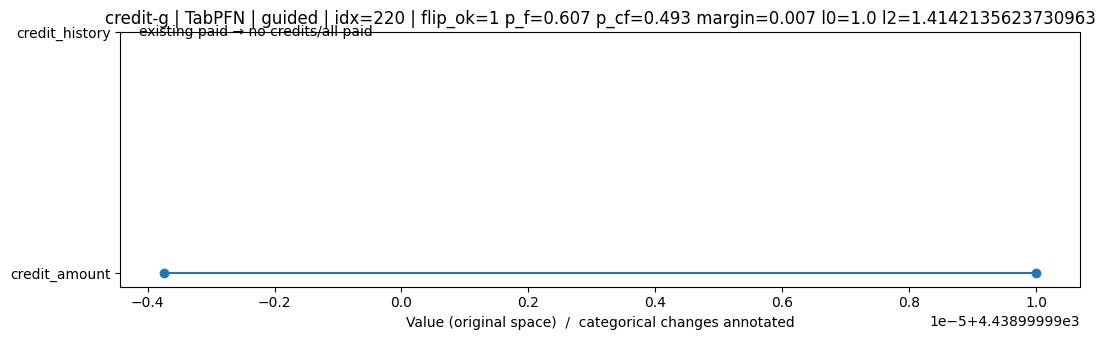

,x_f,x_cf,diff,plaus_flag
credit_amount,4439.0,4438.999986,-0.000014,
credit_history,existing paid,no credits/all paid,NaN,


ValueError: non-broadcastable output operand with shape (1,1) doesn't match the broadcast shape (1,7)

In [ ]:
i = 220
ds_ind = 1
ds = real_datasets[ds_ind].name
model = "TabPFN"

X_train_df_orig = real_datasets[ds_ind].X_df  # or whatever your original-space training df is

for method in ["guided", "nice"]:
    _dfc, row = view_cf_original_space(
        df_all,
        idx=i, dataset=ds, model=model, method=method,
        pre=pre_dict[ds],
        num_cols=real_datasets[ds_ind].num_cols,
        cat_cols=real_datasets[ds_ind].cat_cols,
        X_train_df=X_train_df_orig,   # enables plausibility flags
        top_k=30
    )

In [ ]:
# statuses = (
#     df_all["status"]
#     .fillna("unknown")
#     .unique()
# )
# statuses = sorted(statuses)
# agg = (
#     df_all
#     .groupby(["dataset", "model", "method", "status"])
#     .size()
#     .reset_index(name="count")
# )

# agg["freq"] = agg.groupby(
#     ["dataset", "model", "method"]
# )["count"].transform(lambda x: x / x.sum())

# datasets = agg["dataset"].unique()
# models = agg["model"].unique()
# methods = ["guided", "nice"]

# method_hatch = {
#     "guided": "//",      # diagonal
#     "nice": "\\\\",      # opposite diagonal
#     # if you rename later:
#     # "proposal": "//",
# }

# datasets = agg["dataset"].unique()
# models = agg["model"].unique()
# methods = ["guided", "nice"]
# statuses = sorted(agg["status"].unique())

# fig, axes = plt.subplots(1, len(datasets), figsize=(15, 4), sharey=True)

# if len(datasets) == 1:
#     axes = [axes]

# for ax, ds in zip(axes, datasets):
#     sub = agg[agg["dataset"] == ds]

#     x = np.arange(len(models))
#     width = 0.35

#     for i, method in enumerate(methods):
#         bottom = np.zeros(len(models))

#         for status in statuses:
#             vals = []
#             for m in models:
#                 v = sub[
#                     (sub.model == m) &
#                     (sub.method == method) &
#                     (sub.status == status)
#                 ]["freq"]
#                 vals.append(v.iloc[0] if len(v) else 0.0)

#             bars = ax.bar(
#                 x + (i - 0.5) * width,
#                 vals,
#                 width,
#                 bottom=bottom,
#                 label=status if (i == 0) else None,  # status legend once
#                 hatch=method_hatch.get(method, None),
#                 edgecolor="black",
#                 linewidth=0.5,
#             )

#             bottom += np.array(vals)

#     ax.set_title(ds)
#     ax.set_xticks(x)
#     ax.set_xticklabels(models)
#     ax.set_ylim(0, 1)

# axes[0].set_ylabel("Fraction of outcomes")
# # --- Status legend (colors) ---
# status_handles, status_labels = axes[0].get_legend_handles_labels()
# fig.legend(
#     status_handles,
#     status_labels,
#     title="Status",
#     loc="upper center",
#     ncol=len(statuses),
# )

# # --- Method legend (hatches) ---
# method_handles = [
#     plt.Rectangle((0, 0), 1, 1, facecolor="white",
#                   edgecolor="black", hatch=method_hatch[m])
#     for m in methods
# ]
# fig.legend(
#     method_handles,
#     methods,
#     title="Method",
#     loc="upper right",
# )

# plt.tight_layout(rect=[0, 0, 1, 0.85])
# plt.show()